In [2]:
import os
import cv2
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

# Update these paths to where you have unzipped your MmCows data
DATA_ROOT = '/content/pfa-mmcows/store/data/raw'
IMAGES_DIR = os.path.join(DATA_ROOT, 'visual_data/uwb_synced_images')
LABELS_PATH = os.path.join(DATA_ROOT, 'visual_data/labels/combined_labels.csv') # Example filename
PROJ_MAT_DIR = os.path.join(DATA_ROOT, 'visual_data/proj_mat')

print(f"Loading data from: {DATA_ROOT}")

Loading data from: /content/pfa-mmcows/store/data/raw


In [5]:
import os
import cv2
import matplotlib.pyplot as plt
import glob

# Base path based on your provided structure
BASE_PATH = "/content/pfa-mmcows/store/data/raw/visual_data"
DATE = "0725"
CAM = "cam_1"
# Target directories
img_dir = os.path.join(BASE_PATH, "images", DATE, CAM)
label_dir = os.path.join(BASE_PATH, "labels/combined", DATE, CAM)

# List all images
image_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))

if not image_files:
    print(f"Check your path! No images found in: {img_dir}")
else:
    print(f"Success! Found {len(image_files)} images.")
    print(f"Example filename: {os.path.basename(image_files[0])}")

Success! Found 5040 images.
Example filename: 1690271846_02-57-26.jpg


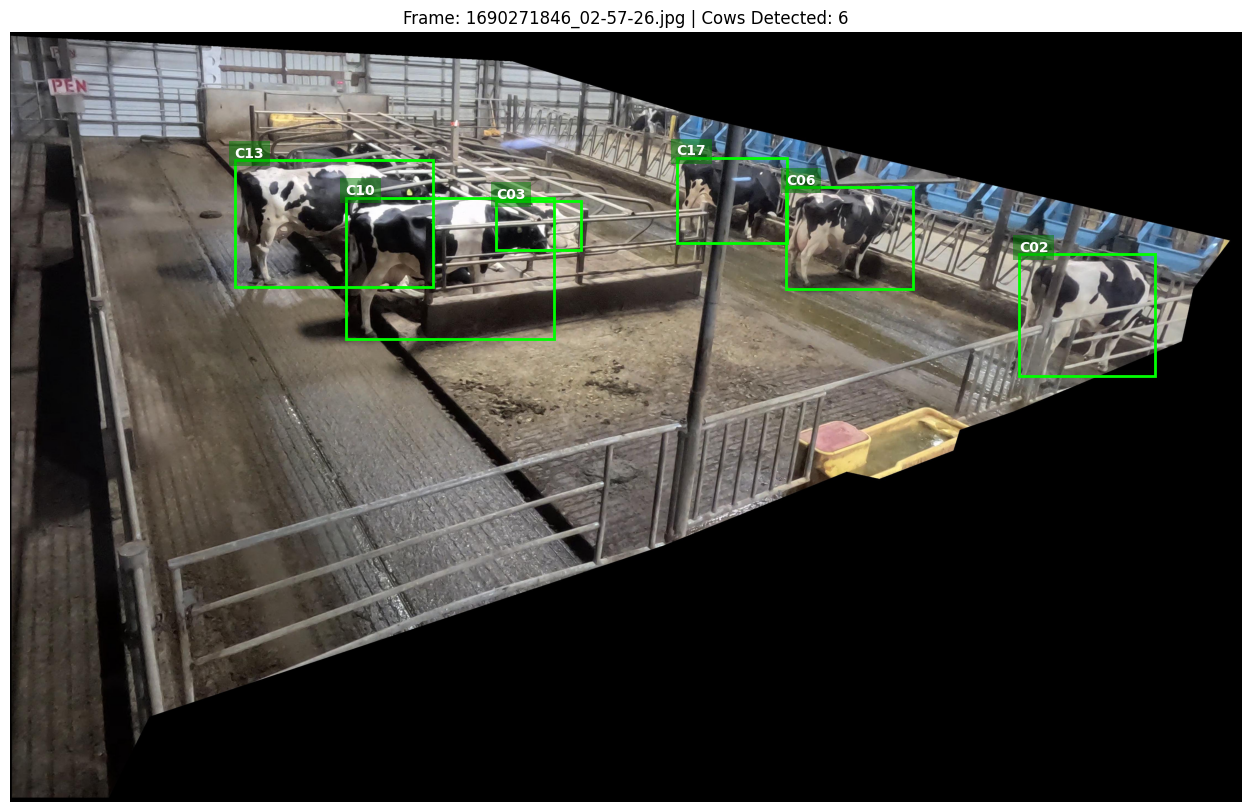

In [7]:
import numpy as np

def visualize_sample(idx=0):
    img_path = image_files[idx]
    img_name = os.path.basename(img_path)
    
    # Match image name to label name (e.g., 1690271846_02-57-26.txt)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))
    
    # Load Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    ax = plt.gca()
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                # YOLO format: <cow_id> <x_center> <y_center> <width> <height>
                data = line.strip().split()
                cow_idx = data[0]
                # Normalized coordinates (0 to 1)
                xc, yc, nw, nh = map(float, data[1:])
                
                # Convert normalized to pixel coordinates
                x1 = (xc - nw/2) * w
                y1 = (yc - nh/2) * h
                bw, bh = nw * w, nh * h
                
                # Draw Rectangle
                rect = plt.Rectangle((x1, y1), bw, bh, fill=False, color='#00FF00', linewidth=2)
                ax.add_patch(rect)
                
                # Label with Cow ID (Commonly C01, C02... in the paper)
                # Note: cow_idx in file is often 0-indexed integer
                display_id = f"C{int(cow_idx)+1:02d}" 
                ax.text(x1, y1-10, display_id, color='white', weight='bold', 
                        bbox=dict(facecolor='green', alpha=0.5, edgecolor='none'))
        
        plt.title(f"Frame: {img_name} | Cows Detected: {len(lines)}")
    else:
        plt.title(f"Frame: {img_name} (No Labels Found)")
        
    plt.axis('off')
    plt.show()

# Visualize the first image in the list
visualize_sample(0)

In [8]:
def check_posture(img_name):
    postures = ['standing', 'lying']
    found_states = {}
    
    for state in postures:
        state_path = os.path.join(BASE_PATH, "labels", state, DATE, CAM, img_name.replace(".jpg", ".txt"))
        if os.path.exists(state_path):
            with open(state_path, 'r') as f:
                # Get the cow IDs present in this posture file
                cows = [line.split()[0] for line in f.readlines()]
                found_states[state] = cows
    
    return found_states

# Example check for the first image
states = check_posture(os.path.basename(image_files[0]))
print(f"Postures for {os.path.basename(image_files[0])}:")
for state, cows in states.items():
    print(f" - {state.capitalize()}: Cows {[f'C{int(c)+1:02d}' for c in cows]}")

Postures for 1690271846_02-57-26.jpg:
 - Standing: Cows ['C10', 'C17', 'C06', 'C13', 'C02']
 - Lying: Cows ['C03']
